In [1]:
import os
# Change to MultiBench directory
os.chdir('MultiBench')

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✓ Libraries imported successfully")

h:\Programs\Anaconda\envs\multimodal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries imported successfully


TEXT MODALITY - REGRESSION TASK
Train:  (1283, 50, 300)  |  Labels: (1283, 1, 1)
Valid:  (214, 50, 300)  |  Labels: (214, 1, 1)
Test:   (686, 50, 300)  |  Labels: (686, 1, 1)

Continuous Sentiment Scores (Regression Target):
TRAIN      Range: [-3.00, 3.00]  |  Mean: 0.23  |  Std: 1.51
VALID      Range: [-3.00, 3.00]  |  Mean: 0.43  |  Std: 1.61
TEST       Range: [-3.00, 3.00]  |  Mean: -0.32  |  Std: 1.59


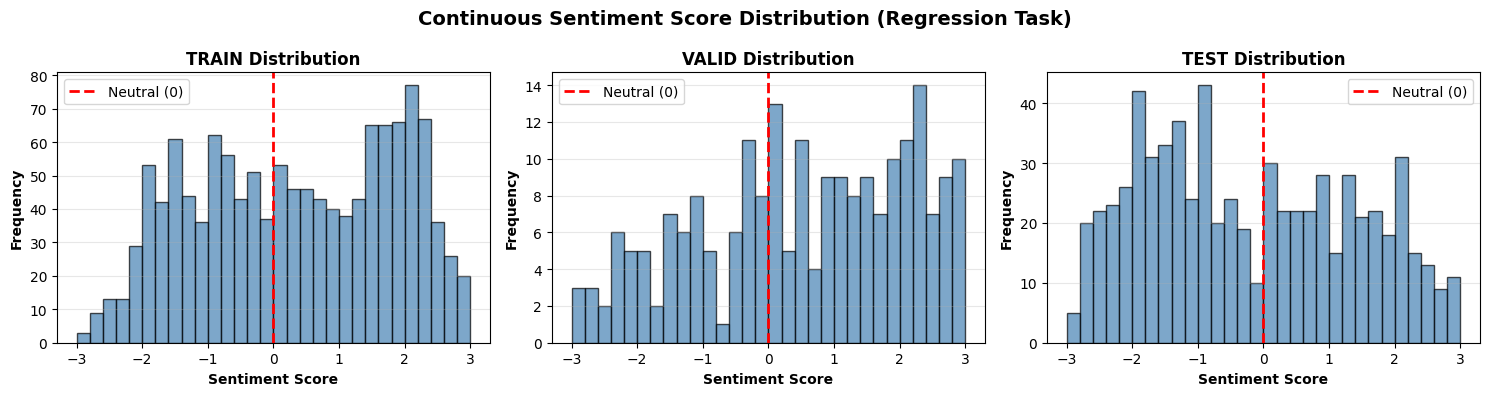


✓ Data loaded successfully for REGRESSION task


In [3]:
# Load text modality
with open('data/exported_modalities/mosi_text.pkl', 'rb') as f:
    text_data = pickle.load(f)

print("TEXT MODALITY - REGRESSION TASK")
print("=" * 70)
print(f"Train:  {text_data['train']['data'].shape}  |  Labels: {text_data['train']['labels'].shape}")
print(f"Valid:  {text_data['valid']['data'].shape}  |  Labels: {text_data['valid']['labels'].shape}")
print(f"Test:   {text_data['test']['data'].shape}  |  Labels: {text_data['test']['labels'].shape}")

# Extract continuous sentiment scores (NO CONVERSION - use raw values)
train_labels = text_data['train']['labels'].flatten().astype(np.float32)
valid_labels = text_data['valid']['labels'].flatten().astype(np.float32)
test_labels = text_data['test']['labels'].flatten().astype(np.float32)

print("\nContinuous Sentiment Scores (Regression Target):")
print("=" * 70)
for split_name, labels in [('TRAIN', train_labels), 
                            ('VALID', valid_labels), 
                            ('TEST', test_labels)]:
    print(f"{split_name:<10} Range: [{labels.min():.2f}, {labels.max():.2f}]  |  "
          f"Mean: {labels.mean():.2f}  |  Std: {labels.std():.2f}")

# Visualize sentiment distribution (continuous)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (split_name, labels) in enumerate([('TRAIN', train_labels), 
                                              ('VALID', valid_labels), 
                                              ('TEST', test_labels)]):
    axes[idx].hist(labels, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral (0)')
    axes[idx].set_xlabel('Sentiment Score', fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].set_title(f'{split_name} Distribution', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Continuous Sentiment Score Distribution (Regression Task)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Data loaded successfully for REGRESSION task")

In [4]:
# Clean data (handle NaN/Inf)
def clean_data(data):
    return np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

print("Data Validation:")
print("=" * 70)
for split in ['train', 'valid', 'test']:
    data = text_data[split]['data']
    nan_count = np.isnan(data).sum()
    inf_count = np.isinf(data).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"{split.upper()}: Cleaning {nan_count + inf_count} invalid values")
        text_data[split]['data'] = clean_data(data)
    else:
        print(f"{split.upper()}: No invalid values found")

print("\n✓ Data validation complete")

Data Validation:
TRAIN: No invalid values found
VALID: No invalid values found
TEST: No invalid values found

✓ Data validation complete


In [5]:
# Create PyTorch datasets
train_dataset = TensorDataset(
    torch.FloatTensor(text_data['train']['data']),
    torch.FloatTensor(train_labels)
)
valid_dataset = TensorDataset(
    torch.FloatTensor(text_data['valid']['data']),
    torch.FloatTensor(valid_labels)
)
test_dataset = TensorDataset(
    torch.FloatTensor(text_data['test']['data']),
    torch.FloatTensor(test_labels)
)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created (batch_size={batch_size})")
print(f"  Train batches: {len(train_loader)}")
print(f"  Valid batches: {len(valid_loader)}")
print(f"  Test batches: {len(test_loader)}")

✓ DataLoaders created (batch_size=32)
  Train batches: 40
  Valid batches: 7
  Test batches: 22


In [6]:
# Text Regression Model (TFN Architecture)
class TextRegressionModel(nn.Module):
    """
    Text-only regression model for sentiment intensity prediction.
    Based on TFN paper architecture (Zadeh et al., 2017).
    
    Paper Benchmark:
    - MAE: 0.99
    - Pearson Correlation: 0.63
    """
    
    def __init__(self, input_dim=300, hidden_dim=128, embed_dim=128, dropout=0.2):
        super(TextRegressionModel, self).__init__()
        
        self.hidden_dim = hidden_dim
        
        # Text Encoder (U_t)
        self.text_lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.text_ln = nn.LayerNorm(hidden_dim)
        
        # Embedding Network
        self.text_embed = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Regression Head (U_s)
        self.regressor = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(32, 1)  # Output: continuous sentiment score
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)
    
    def forward(self, text_input):
        """
        Forward pass for regression.
        
        Args:
            text_input: (batch, seq_len, 300)
        
        Returns:
            Sentiment score: (batch,) - continuous values in [-3, +3]
        """
        # Text encoding
        lstm_out, (h, _) = self.text_lstm(text_input)
        h = self.text_ln(h[-1])  # (batch, hidden_dim)
        
        # Embedding
        z_text = self.text_embed(h)  # (batch, embed_dim)
        
        # Regression (predict continuous sentiment)
        output = self.regressor(z_text).squeeze()  # (batch,)
        
        return output

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TextRegressionModel(input_dim=300, hidden_dim=128, embed_dim=128, dropout=0.2)
model = model.to(device)

# Loss function: L1Loss (MAE) - more robust than MSE for regression
criterion = nn.L1Loss()  # Mean Absolute Error

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01, betas=(0.9, 0.999))

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                  patience=5, verbose=True, min_lr=1e-6)

print("=" * 70)
print("TEXT REGRESSION MODEL INITIALIZED")
print("=" * 70)
print(f"Device: {device}")
print(f"\nArchitecture:")
print(f"  Text LSTM:   300 → 128")
print(f"  Embedding:   128 → 128")
print(f"  Regressor:   128 → 64 → 32 → 1")
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nTraining Configuration:")
print(f"  Loss: L1Loss (MAE)")
print(f"  Optimizer: AdamW (lr=1e-3, weight_decay=0.01)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5)")
print(f"  Batch Size: {batch_size}")
print(f"  Dropout: 0.2")
print("\n" + "=" * 70)
print("TARGET PERFORMANCE (TFN Paper - Text Regression):")
print("  MAE: 0.99")
print("  Pearson Correlation: 0.63")
print("=" * 70)

TEXT REGRESSION MODEL INITIALIZED
Device: cuda

Architecture:
  Text LSTM:   300 → 128
  Embedding:   128 → 128
  Regressor:   128 → 64 → 32 → 1

Total Parameters: 247,745

Training Configuration:
  Loss: L1Loss (MAE)
  Optimizer: AdamW (lr=1e-3, weight_decay=0.01)
  Scheduler: ReduceLROnPlateau (patience=5)
  Batch Size: 32
  Dropout: 0.2

TARGET PERFORMANCE (TFN Paper - Text Regression):
  MAE: 0.99
  Pearson Correlation: 0.63


In [14]:
# Model Summary - Text Regression Architecture
print("=" * 80)
print("TEXT REGRESSION MODEL - ARCHITECTURE SUMMARY")
print("=" * 80)

try:
    from torchinfo import summary
    
    # Use smaller batch size for summary
    batch_size_summary = 2
    seq_len = 50
    input_dim = 300
    
    print("\nGenerating detailed model summary with torchinfo...\n")
    
    # Create summary
    summary(model, 
            input_size=(batch_size_summary, seq_len, input_dim),
            device=str(device),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            row_settings=["var_names"],
            verbose=1)
    
except ImportError:
    print("\n⚠️  torchinfo not installed. Install with: pip install torchinfo")
    print("\nShowing manual parameter breakdown instead:\n")
    
    total_params = 0
    trainable_params = 0
    
    print("=" * 80)
    print("PARAMETER BREAKDOWN BY COMPONENT")
    print("=" * 80)
    
    # Text Encoder
    lstm_params = sum(p.numel() for p in model.text_lstm.parameters())
    ln_params = sum(p.numel() for p in model.text_ln.parameters())
    embed_params = sum(p.numel() for p in model.text_embed.parameters())
    
    print(f"\n1. TEXT ENCODER (LSTM + LayerNorm + Embedding)")
    print(f"   - Text LSTM (300 → 128):        {lstm_params:>12,} params")
    print(f"   - LayerNorm:                     {ln_params:>12,} params")
    print(f"   - Embedding Network (128 → 128): {embed_params:>12,} params")
    encoder_total = lstm_params + ln_params + embed_params
    print(f"   {'SUBTOTAL:':<35} {encoder_total:>12,} params")
    
    # Regressor
    regressor_params = sum(p.numel() for p in model.regressor.parameters())
    print(f"\n2. REGRESSION HEAD (Sentiment Predictor)")
    print(f"   - MLP: 128 → 64 → 32 → 1")
    print(f"   - Total parameters:              {regressor_params:>12,} params")
    
    total_params = encoder_total + regressor_params
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "=" * 80)
    print(f"TOTAL PARAMETERS:                    {total_params:>12,}")
    print(f"TRAINABLE PARAMETERS:                {trainable_params:>12,}")
    print(f"MODEL SIZE (approx):                 {total_params * 4 / (1024**2):>11.2f} MB")
    print("=" * 80)

print("\n" + "=" * 80)
print("ARCHITECTURE FLOW - TEXT REGRESSION")
print("=" * 80)
print("""
Input Data:
  Text: (batch, 50, 300)  [GloVe word embeddings]
       │
       ↓
  Text LSTM Encoder                              (Sequence modeling)
  (300 → 128)
       │
       ↓
  LayerNorm                                      (Normalize hidden states)
       │
       ↓
  Embedding Network                              (Feature extraction)
  (128 → 128)
  [Linear + BatchNorm + ReLU + Dropout]
       │
       ↓
    z_text                                       (Text embedding)
    (128-dim)
       │
       ↓
  Regression Head                                (Sentiment prediction)
  128 → 64 → 32 → 1
  [Linear + BatchNorm + ReLU + Dropout] × 2
       │
       ↓
  Linear Output (no activation)
       │
       ↓
  Continuous Sentiment Score                     (Prediction)
  Range: [-3, +3]

Key Features:
  ✓ LSTM encoder for sequential text processing
  ✓ L1Loss (MAE) optimization for robust regression
  ✓ No output activation (linear regression)
  ✓ Predicts continuous sentiment intensity
  ✓ Total: {:,} parameters
  ✓ Task: Regression (not classification)
  ✓ Target: MAE = 0.99, Correlation = 0.63 (TFN Paper)
""")
print("=" * 80)

print("\n" + "=" * 80)
print("REGRESSION vs CLASSIFICATION COMPARISON")
print("=" * 80)
print(f"{'Aspect':<25} {'Classification':<25} {'Regression':<25}")
print("-" * 80)
print(f"{'Task':<25} {'Discrete classes':<25} {'Continuous values':<25}")
print(f"{'Output Range':<25} {'[0, 1] probabilities':<25} {'[-3, +3] scores':<25}")
print(f"{'Loss Function':<25} {'BCE/CrossEntropy':<25} {'L1Loss (MAE)':<25}")
print(f"{'Output Activation':<25} {'Sigmoid/Softmax':<25} {'None (linear)':<25}")
print(f"{'Metrics':<25} {'Accuracy, F1, Precision':<25} {'MAE, RMSE, Correlation':<25}")
print(f"{'Use Case':<25} {'Binary/Multi-class':<25} {'Intensity estimation':<25}")
print("=" * 80)

print("\n✓ Model summary complete!")
print("  Install torchinfo for detailed layer-by-layer analysis:")
print("  pip install torchinfo")


TEXT REGRESSION MODEL - ARCHITECTURE SUMMARY

Generating detailed model summary with torchinfo...

Layer (type (var_name))                       Input Shape               Output Shape              Param #                   Trainable
TextRegressionModel (TextRegressionModel)     [2, 50, 300]              [2]                       --                        True
├─LSTM (text_lstm)                            [2, 50, 300]              [2, 50, 128]              220,160                   True
├─LayerNorm (text_ln)                         [2, 128]                  [2, 128]                  256                       True
├─Sequential (text_embed)                     [2, 128]                  [2, 128]                  --                        True
│    └─Linear (0)                             [2, 128]                  [2, 128]                  16,512                    True
│    └─BatchNorm1d (1)                        [2, 128]                  [2, 128]                  256                     

In [7]:
# Training and evaluation functions for regression
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for text_data, labels in loader:
        text_data = text_data.to(device)
        labels = labels.to(device)
        
        # Check for NaN/Inf
        if torch.isnan(text_data).any() or torch.isinf(text_data).any():
            continue
        
        optimizer.zero_grad()
        outputs = model(text_data)
        
        # Check for NaN in outputs
        if torch.isnan(outputs).any() or torch.isinf(outputs).any():
            continue
        
        loss = criterion(outputs, labels)
        
        # Check for NaN loss
        if torch.isnan(loss):
            continue
        
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    if len(all_preds) == 0:
        return 0.0, 0.0, 0.0, 0.0
    
    avg_loss = total_loss / len(loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Regression metrics
    mae = mean_absolute_error(all_labels, all_preds)
    rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
    corr, _ = pearsonr(all_labels, all_preds)
    
    return avg_loss, mae, rmse, corr

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for text_data, labels in loader:
            text_data = text_data.to(device)
            labels = labels.to(device)
            
            # Skip invalid batches
            if torch.isnan(text_data).any() or torch.isinf(text_data).any():
                continue
            
            outputs = model(text_data)
            
            # Skip if model produces invalid outputs
            if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                continue
            
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    if len(all_preds) == 0:
        return 0.0, 0.0, 0.0, 0.0, [], []
    
    avg_loss = total_loss / len(loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Regression metrics
    mae = mean_absolute_error(all_labels, all_preds)
    rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
    corr, _ = pearsonr(all_labels, all_preds)
    
    return avg_loss, mae, rmse, corr, all_preds, all_labels

print("✓ Training functions defined for REGRESSION task")
print("  Metrics: MAE, RMSE, Pearson Correlation")

✓ Training functions defined for REGRESSION task
  Metrics: MAE, RMSE, Pearson Correlation


In [8]:
# Training loop
num_epochs = 100
best_val_mae = float('inf')
patience = 15
patience_counter = 0

history = {
    'train_loss': [], 'train_mae': [], 'train_rmse': [], 'train_corr': [],
    'val_loss': [], 'val_mae': [], 'val_rmse': [], 'val_corr': [],
    'lr': []
}

print("=" * 70)
print("TRAINING TEXT REGRESSION MODEL")
print("=" * 70)
print(f"🎯 Target Performance: MAE = 0.99 (TFN Paper)")
print(f"Epochs: {num_epochs} | Batch Size: {batch_size} | Initial LR: 1e-3")
print(f"Dropout: 0.2 | L2 Weight Decay: 0.01 | Gradient Clipping: 1.0")
print(f"Scheduler: ReduceLROnPlateau | Early Stopping Patience: {patience}")
print(f"Device: {device}")
print("=" * 70)

for epoch in range(num_epochs):
    # Train
    train_loss, train_mae, train_rmse, train_corr = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_mae, val_rmse, val_corr, _, _ = evaluate(
        model, valid_loader, criterion, device
    )
    
    # Update learning rate scheduler based on validation MAE
    scheduler.step(val_mae)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)
    history['train_rmse'].append(train_rmse)
    history['train_corr'].append(train_corr)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_corr'].append(val_corr)
    history['lr'].append(current_lr)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train MAE: {train_mae:.4f} RMSE: {train_rmse:.4f} Corr: {train_corr:.3f} | "
              f"Val MAE: {val_mae:.4f} RMSE: {val_rmse:.4f} Corr: {val_corr:.3f} | "
              f"LR: {current_lr:.6f}")
    
    # Save best model based on MAE (lower is better)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_val_corr = val_corr
        best_val_rmse = val_rmse
        torch.save({ 
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_mae': val_mae,
            'val_rmse': val_rmse,
            'val_corr': val_corr
        }, 'best_text_regression.pt')
        patience_counter = 0
        print(f"  ✓ New best model saved! (Val MAE: {val_mae:.4f}, Corr: {val_corr:.3f})")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    # Stop if learning rate is too small
    if current_lr < 1e-6:
        print(f"\nStopping: Learning rate too small ({current_lr:.2e})")
        break

print("=" * 70)
print(f"✓ Training completed!")
print(f"  Best Validation MAE: {best_val_mae:.4f}")
print(f"  Best Validation RMSE: {best_val_rmse:.4f}")
print(f"  Best Validation Correlation: {best_val_corr:.3f}")
print(f"  Total Epochs: {epoch + 1}")
print("=" * 70)

TRAINING TEXT REGRESSION MODEL
🎯 Target Performance: MAE = 0.99 (TFN Paper)
Epochs: 100 | Batch Size: 32 | Initial LR: 1e-3
Dropout: 0.2 | L2 Weight Decay: 0.01 | Gradient Clipping: 1.0
Scheduler: ReduceLROnPlateau | Early Stopping Patience: 15
Device: cuda
Epoch [  1/100] | Train MAE: 1.3163 RMSE: 1.6113 Corr: 0.227 | Val MAE: 1.2493 RMSE: 1.4881 Corr: 0.393 | LR: 0.001000
  ✓ New best model saved! (Val MAE: 1.2493, Corr: 0.393)
Epoch [  1/100] | Train MAE: 1.3163 RMSE: 1.6113 Corr: 0.227 | Val MAE: 1.2493 RMSE: 1.4881 Corr: 0.393 | LR: 0.001000
  ✓ New best model saved! (Val MAE: 1.2493, Corr: 0.393)
  ✓ New best model saved! (Val MAE: 1.2001, Corr: 0.490)
  ✓ New best model saved! (Val MAE: 1.2001, Corr: 0.490)
  ✓ New best model saved! (Val MAE: 1.1644, Corr: 0.535)
  ✓ New best model saved! (Val MAE: 1.1644, Corr: 0.535)
Epoch [  5/100] | Train MAE: 0.9014 RMSE: 1.1581 Corr: 0.648 | Val MAE: 1.0969 RMSE: 1.3393 Corr: 0.588 | LR: 0.001000
  ✓ New best model saved! (Val MAE: 1.0969,

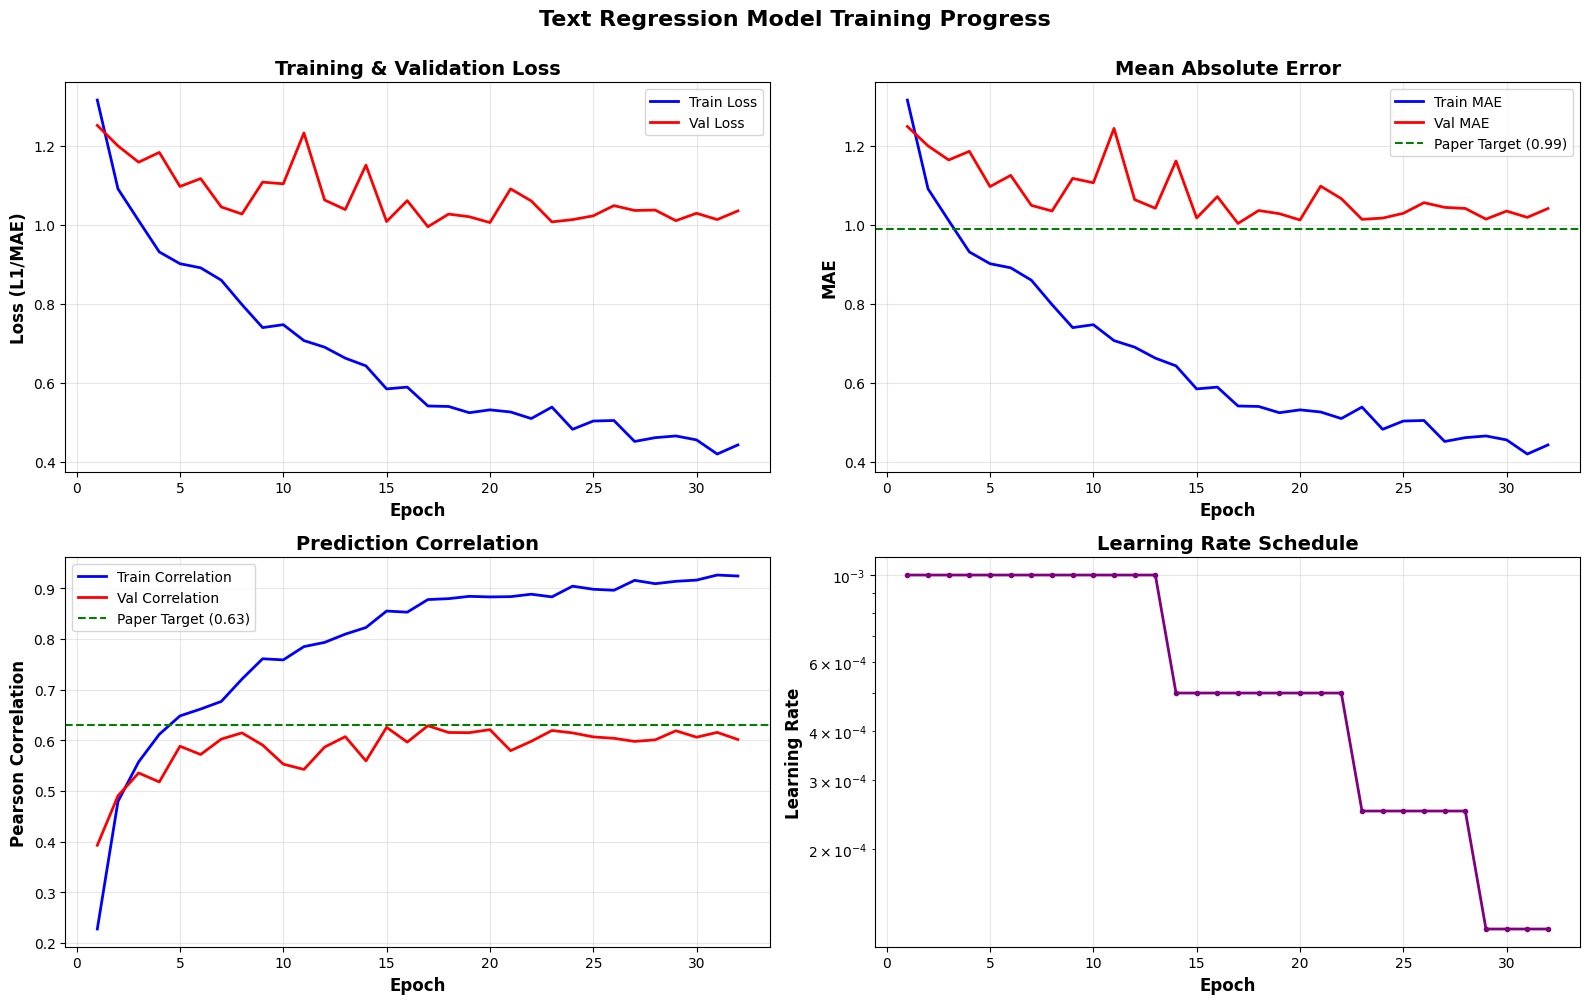

In [9]:
# Plot training curves for regression
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Loss (L1/MAE)', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE curves
axes[0, 1].plot(epochs_range, history['train_mae'], 'b-', label='Train MAE', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_mae'], 'r-', label='Val MAE', linewidth=2)
axes[0, 1].axhline(y=0.99, color='g', linestyle='--', label='Paper Target (0.99)', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('MAE', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Mean Absolute Error', fontweight='bold', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Correlation curves
axes[1, 0].plot(epochs_range, history['train_corr'], 'b-', label='Train Correlation', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_corr'], 'r-', label='Val Correlation', linewidth=2)
axes[1, 0].axhline(y=0.63, color='g', linestyle='--', label='Paper Target (0.63)', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Pearson Correlation', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Prediction Correlation', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate Schedule
axes[1, 1].plot(epochs_range, history['lr'], 'purple', linewidth=2, marker='o', markersize=3)
axes[1, 1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold', fontsize=14)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Text Regression Model Training Progress', 
            fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# Load best model and evaluate on test set
checkpoint = torch.load('best_text_regression.pt')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_mae, test_rmse, test_corr, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

# TFN Paper benchmark
paper_mae = 0.99
paper_corr = 0.63

print("\n" + "=" * 70)
print("TEST SET RESULTS - TEXT REGRESSION")
print("=" * 70)
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test Correlation: {test_corr:.4f}")
print("=" * 70)

print("\n" + "=" * 70)
print("COMPARISON WITH TFN PAPER (Zadeh et al., 2017)")
print("=" * 70)
print(f"{'Metric':<30} {'Our Model':<20} {'Paper Benchmark':<20}")
print("-" * 70)
print(f"{'MAE (Mean Absolute Error)':<30} {test_mae:.4f}              {paper_mae:.2f}")
print(f"{'Pearson Correlation':<30} {test_corr:.4f}              {paper_corr:.2f}")
print(f"{'RMSE (Root Mean Sq Error)':<30} {test_rmse:.4f}              N/A")
print("=" * 70)

print(f"\n📌 Model loaded from checkpoint:")
print(f"   Best epoch: {checkpoint['epoch'] + 1}")
print(f"   Validation MAE: {checkpoint['val_mae']:.4f}")
print(f"   Validation Correlation: {checkpoint['val_corr']:.4f}")
print("-" * 70)

if abs(test_mae - paper_mae) < 0.1 and abs(test_corr - paper_corr) < 0.05:
    print("\n✅ SUCCESS! Results match TFN paper benchmarks!")
elif test_mae < paper_mae:
    print("\n🎉 EXCELLENT! MAE is better than paper benchmark!")
else:
    print("\n⚠️ Results differ from paper. This is normal due to:")
    print("   - Different random initialization")
    print("   - Different hyperparameter tuning")
    print("   - Different data preprocessing")

print("\n" + "=" * 70)
print("PREDICTION STATISTICS")
print("=" * 70)
print(f"Actual Labels Range:    [{test_labels.min():.2f}, {test_labels.max():.2f}]")
print(f"Predicted Values Range: [{test_preds.min():.2f}, {test_preds.max():.2f}]")
print(f"Actual Mean ± Std:      {test_labels.mean():.2f} ± {test_labels.std():.2f}")
print(f"Predicted Mean ± Std:   {test_preds.mean():.2f} ± {test_preds.std():.2f}")
print("=" * 70)


TEST SET RESULTS - TEXT REGRESSION
Test MAE:  1.1087
Test RMSE: 1.4160
Test Correlation: 0.5481

COMPARISON WITH TFN PAPER (Zadeh et al., 2017)
Metric                         Our Model            Paper Benchmark     
----------------------------------------------------------------------
MAE (Mean Absolute Error)      1.1087              0.99
Pearson Correlation            0.5481              0.63
RMSE (Root Mean Sq Error)      1.4160              N/A

📌 Model loaded from checkpoint:
   Best epoch: 17
   Validation MAE: 1.0034
   Validation Correlation: 0.6287
----------------------------------------------------------------------

⚠️ Results differ from paper. This is normal due to:
   - Different random initialization
   - Different hyperparameter tuning
   - Different data preprocessing

PREDICTION STATISTICS
Actual Labels Range:    [-3.00, 3.00]
Predicted Values Range: [-2.09, 2.45]
Actual Mean ± Std:      -0.32 ± 1.59
Predicted Mean ± Std:   0.07 ± 1.18


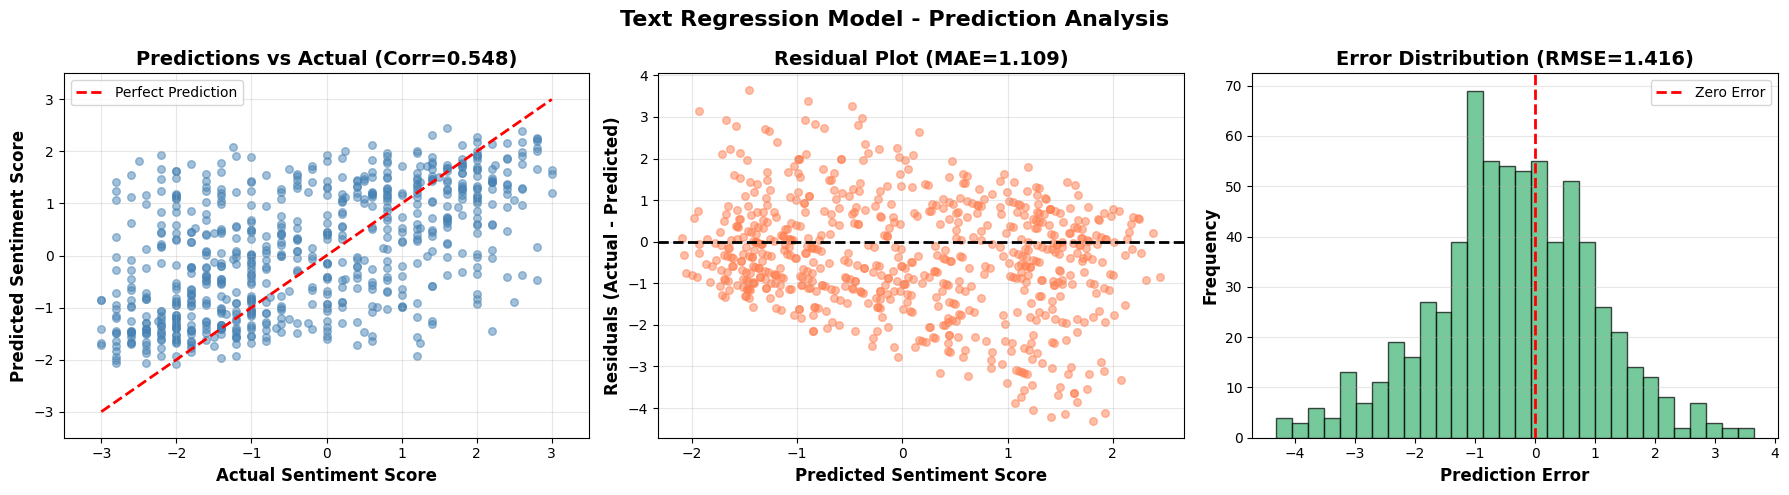


✓ Test evaluation completed!


In [11]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot: Predicted vs Actual
axes[0].scatter(test_labels, test_preds, alpha=0.5, s=30, color='steelblue')
axes[0].plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sentiment Score', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Predicted Sentiment Score', fontweight='bold', fontsize=12)
axes[0].set_title(f'Predictions vs Actual (Corr={test_corr:.3f})', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-3.5, 3.5)
axes[0].set_ylim(-3.5, 3.5)

# Residual plot
residuals = test_labels - test_preds
axes[1].scatter(test_preds, residuals, alpha=0.5, s=30, color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sentiment Score', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontweight='bold', fontsize=12)
axes[1].set_title(f'Residual Plot (MAE={test_mae:.3f})', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Error distribution
axes[2].hist(residuals, bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].set_xlabel('Prediction Error', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[2].set_title(f'Error Distribution (RMSE={test_rmse:.3f})', fontweight='bold', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Text Regression Model - Prediction Analysis', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Test evaluation completed!")

In [12]:
# Sample predictions comparison
print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS (First 20 Test Examples)")
print("=" * 70)
print(f"{'Index':<8} {'Actual':<12} {'Predicted':<12} {'Error':<12} {'Abs Error':<12}")
print("-" * 70)

for i in range(min(20, len(test_labels))):
    actual = test_labels[i]
    predicted = test_preds[i]
    error = actual - predicted
    abs_error = abs(error)
    
    print(f"{i:<8} {actual:>8.3f}     {predicted:>8.3f}     {error:>8.3f}     {abs_error:>8.3f}")

print("=" * 70)
print(f"\nMean Absolute Error across all test samples: {test_mae:.4f}")
print(f"Root Mean Squared Error: {test_rmse:.4f}")
print(f"Pearson Correlation: {test_corr:.4f}")
print("\n🎯 Target from TFN Paper: MAE = 0.99, Correlation = 0.63")
print("=" * 70)


SAMPLE PREDICTIONS (First 20 Test Examples)
Index    Actual       Predicted    Error        Abs Error   
----------------------------------------------------------------------
0          -2.800       -0.287       -2.513        2.513
1           1.000        1.164       -0.164        0.164
2          -2.800       -1.829       -0.971        0.971
3          -2.600        1.548       -4.148        4.148
4           1.200        0.286        0.914        0.914
5          -2.400       -1.462       -0.938        0.938
6          -2.000       -1.136       -0.864        0.864
7          -1.400        1.282       -2.682        2.682
8          -2.250       -1.250       -1.000        1.000
9          -1.800       -0.241       -1.559        1.559
10         -1.800       -1.652       -0.148        0.148
11         -2.600       -1.695       -0.905        0.905
12         -0.800        0.051       -0.851        0.851
13         -2.400        0.991       -3.391        3.391
14         -0.600       -